In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## The IRIS dataset

In the following we start using a [dataset](https://archive.ics.uci.edu/dataset/53/iris) (from UCI Machine Learning repository) called IRIS, which contains 3 classes of iris plants (*setosa*, *versicolor*, *virginica*) with 4 features (*sepal length*, *sepal width*, *petal length*, *petal width*).

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


## Model declaration

The type of prediction model and the working criteria for the model induction algorithm are declared using scikit-learn. In this case, we use a Multi-layer Perceptron (MLP) classifier. The parametrization of this first classifier is arbitrary and will result in subpar performance.

In [ ]:
from sklearn.neural_network import MLPClassifier
clf_ANN = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1, max_iter=2000)

## Training and test sets

We split the dataset in a training set (to be used to fit the model) and a test set (to be used to evaluate the quality of the fitted model). In this case, we keep only 10 examples for testing selected randomly from the original dataset (using numpy).

In [ ]:
np.random.seed(0)

# Generate a random permutation of the indices of examples that will be later used
# for the training and the test set
indices = np.random.permutation(len(iris.data))

# We now decide to keep the last 10 indices for test set, the remaining for the training set
indices_training=indices[:-10]
indices_test=indices[-10:]

iris_X_train = iris.data[indices_training] # keep for training all the matrix elements with the exception of the last 10
iris_y_train = iris.target[indices_training]
iris_X_test  = iris.data[indices_test] # keep the last 10 elements for test set
iris_y_test  = iris.target[indices_test]

In [ ]:
# fit the model to the training data
clf_ANN = clf_ANN.fit(iris_X_train, iris_y_train)
print("Training set score: " + str(clf_ANN.score(iris_X_train, iris_y_train)))
print("Training set loss: " + str(clf_ANN.loss_))

Training set score: 0.6714285714285714
Training set loss: 0.5559834895588641


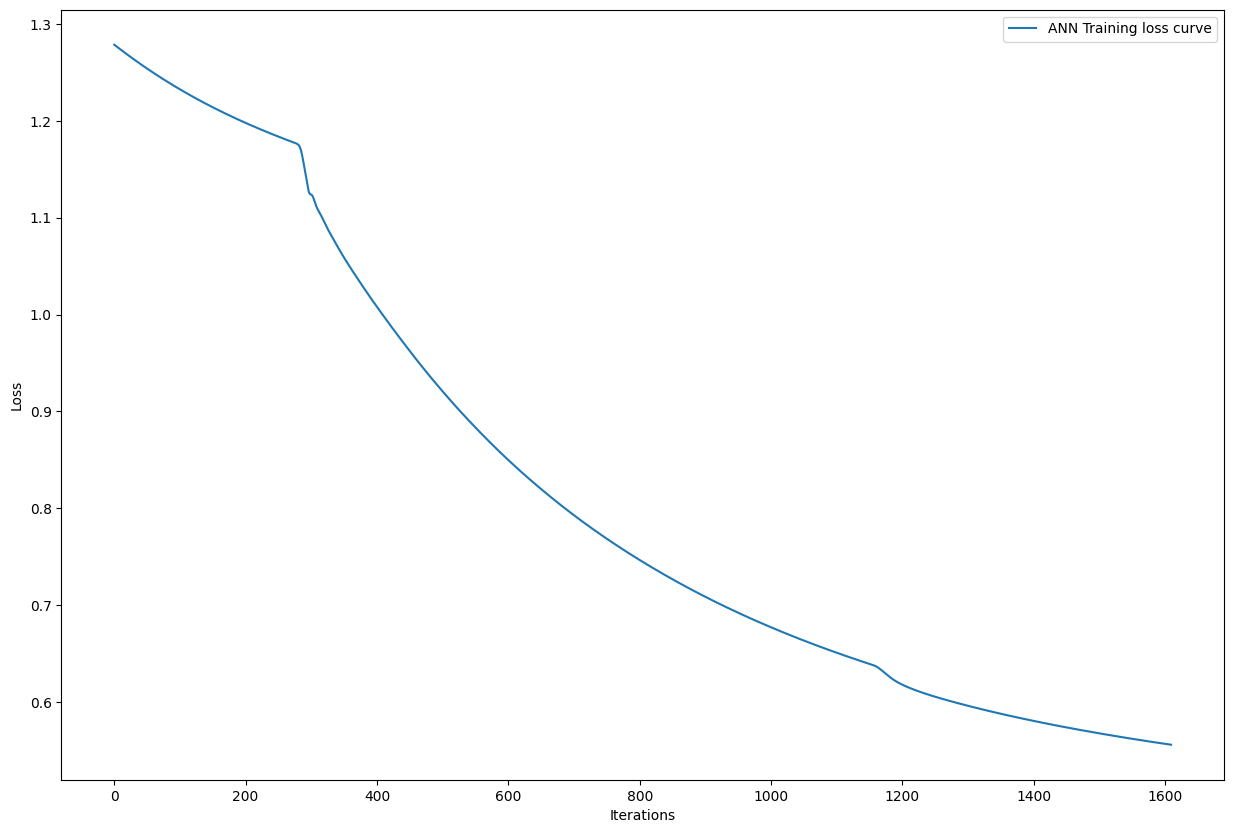

In [ ]:
# Viene monitorato l'andamento della funzione di loss

# The learning curve is plotted using Matplotlib
fig, axis = plt.subplots(1, figsize=(15, 10))
axis.set_xlabel("Iterations")
axis.set_ylabel("Loss")
axis.plot(clf_ANN.loss_curve_, label="ANN Training loss curve")
axis.legend()

The training loss curve can be plotted to visualize how Loss evolves during training. Beware that this curve is not gathered by all optimizers (Adam does, LBFGS doesn't).

**Adam ** is a popular and efficient ML optimizer that uses the first and second moments of the gradients to adaptively adjust the learning rate for each parameter during training. It combines *Momentum* (accelerates convergence with a moving average of past gradients) and *RMSProp* (uses the decaying moving average of squared gradients) to smooth out oscillations and prevent the vanishing or exploding gradient problems.

In [ ]:
clf_ANN_sdg = MLPClassifier(solver='sgd', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1, max_iter=2000)
clf_ANN_sdg = clf_ANN_sdg.fit(iris_X_train, iris_y_train)

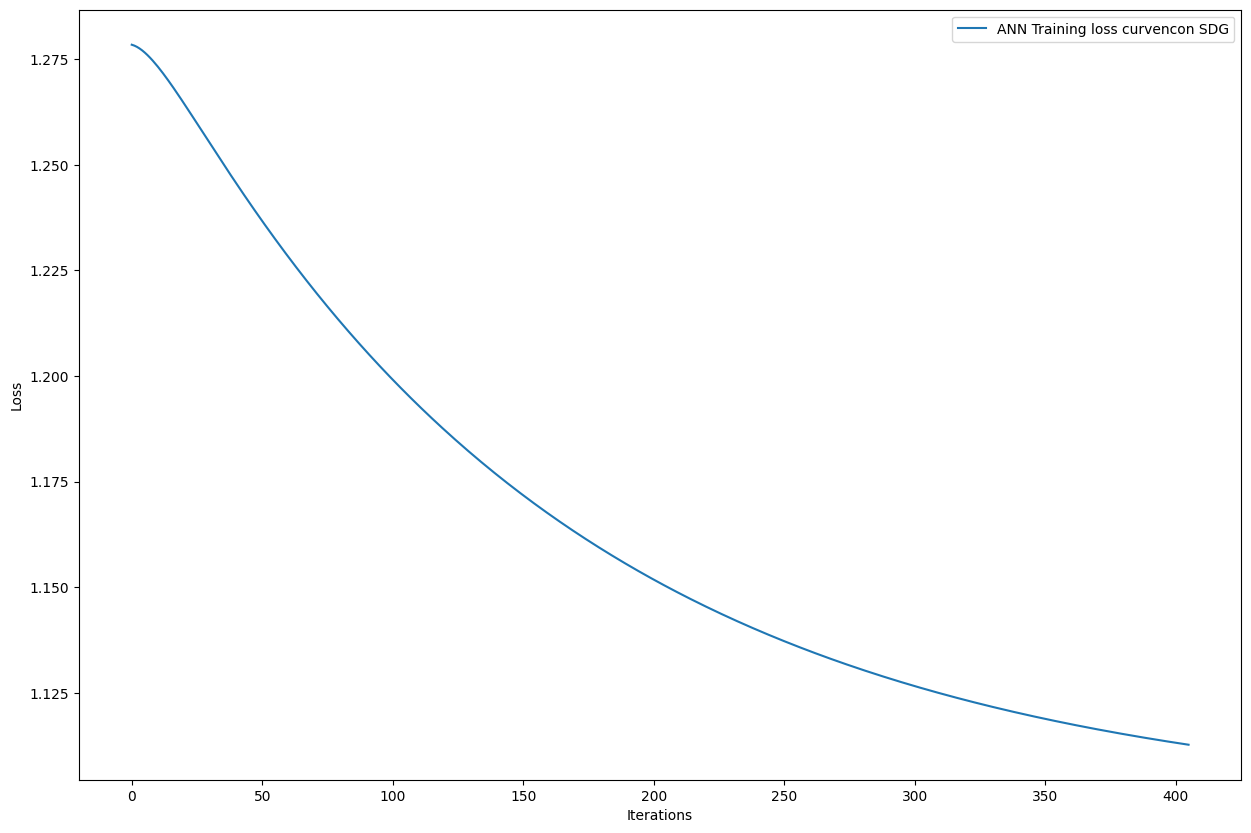

In [ ]:
# The learning curve is plotted using Matplotlib
fig, axis = plt.subplots(1, figsize=(15, 10))
axis.set_xlabel("Iterations")
axis.set_ylabel("Loss")
axis.plot(clf_ANN_sdg.loss_curve_, label="ANN Training loss curvencon SDG")
axis.legend()

Once the model has been trained, it can be used to predict the class of the flowers in the test set.

In [ ]:
predicted_y_test = clf_ANN.predict(iris_X_test)

print(iris.target_names)

# print the predictions (class numbers associated to classes names in target names)
print("\nPredictions:")
print(predicted_y_test)
print("True classes:")
print(iris_y_test)

['setosa' 'versicolor' 'virginica']

Predictions:
[2 2 2 0 0 0 2 2 2 0]
True classes:
[1 1 1 0 0 0 2 1 2 0]


In [ ]:
results_data = []

for i in range(len(iris_y_test)):
    feature_values = [iris_X_test[i][j] for j in range(len(iris.feature_names))]

    results_data.append({
        'Instance': indices_test[i],
        iris.feature_names[0]: feature_values[0],
        iris.feature_names[1]: feature_values[1],
        iris.feature_names[2]: feature_values[2],
        iris.feature_names[3]: feature_values[3],
        'Predicted': iris.target_names[predicted_y_test[i]],
        'True Class': iris.target_names[iris_y_test[i]],
        'Correct': 'Yes' if predicted_y_test[i] == iris_y_test[i] else 'No'
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False, float_format='%.1f'))

 Instance  sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) Predicted True Class Correct
       88                5.6               3.0                4.1               1.3 virginica versicolor      No
       70                5.9               3.2                4.8               1.8 virginica versicolor      No
       87                6.3               2.3                4.4               1.3 virginica versicolor      No
       36                5.5               3.5                1.3               0.2    setosa     setosa     Yes
       21                5.1               3.7                1.5               0.4    setosa     setosa     Yes
        9                4.9               3.1                1.5               0.1    setosa     setosa     Yes
      103                6.3               2.9                5.6               1.8 virginica  virginica     Yes
       67                5.8               2.7                4.1               1.0 virginica ve

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [ ]:
# print some metrics results
acc_scoreANN = accuracy_score(iris_y_test, predicted_y_test)
print("Accuracy score ANN: "+ str(acc_scoreANN))
f1=f1_score(iris_y_test, predicted_y_test, average='macro')
print("F1 score ANN: "+ str(f1))

Accuracy score ANN: 0.6
F1 score ANN: 0.5


## Cross Validation

Scikit-learn provides several built-in functions to perform cross-validation. In this case we use a $5$-fold cross-validation, and we compute the accuracy and F1-score for each fold.

In [ ]:
from sklearn.model_selection import cross_val_score # will be used to separate training and test

iris = load_iris()
clf_ANN = MLPClassifier(solver='lbfgs', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1)

scoresANN = cross_val_score(clf_ANN, iris.data, iris.target, cv=5) # score will be the accuracy
f1_scoresANN = cross_val_score(clf_ANN, iris.data, iris.target, cv=5, scoring='f1_macro')

print(scoresANN)
print(f1_scoresANN)

[0.33333333 0.33333333 0.33333333 0.33333333 0.33333333]
[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


Scikit-learn provides built-in facilities to visualize learning curves, by also employing CV on training set of increasing size, allowing to visualize overfitting/underfitting phenomena.

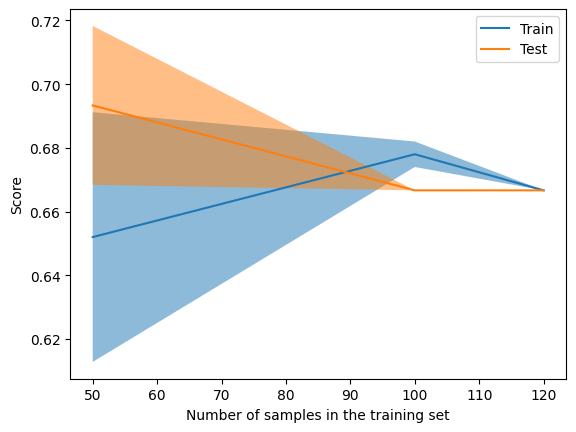

In [ ]:
from sklearn.model_selection import LearningCurveDisplay
from sklearn.utils import shuffle

iris_x, iris_y = load_iris(return_X_y=True)
iris_x, iris_y = shuffle(iris_x, iris_y, random_state=0)
clf_ANN = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=1, max_iter=2000)
LearningCurveDisplay.from_estimator(clf_ANN, iris_x, iris_y, train_sizes=[50, 100, 120], cv=5)

P.S. certain optimizers (like Adam) raise several convergence warnings if the maximum number of iterations is not sufficient to reach convergence. This can be visually problematic especially when trying to search for best hyperparameters (try to run the above cell with `max_iter=400`). In this case, it is possible to disable the warnings as follows:

```python
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
```

### 1. build and show the confusion matrix obtained by cross validation, where the errors are on the test sets.

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
from sklearn.exceptions import ConvergenceWarning

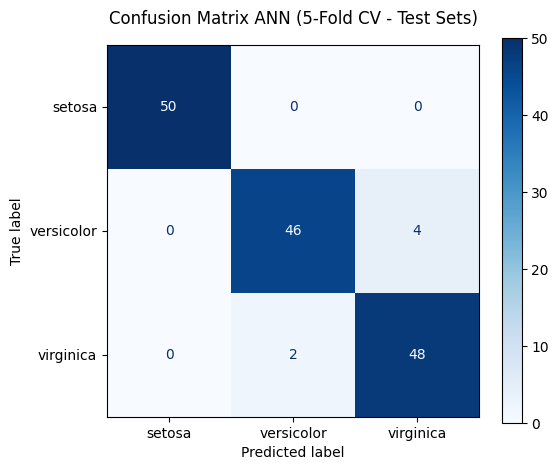

Classification Report ANN (Cross-Validation Test Sets):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.96      0.92      0.94        50
   virginica       0.92      0.96      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [4]:
# Caricamento del dataset
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names

# Inizializzazione della Rete Neurale (MLP)
# Architettura di due hiddel_layers con 10 neuroni ciasuno (10, 10)
# e più iterazioni per favorire la convergenza
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

# Configurazione della Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generazione delle predizioni sui test set (out-of-fold)
y_pred_cv = cross_val_predict(mlp, X, y, cv=cv)

# Calcolo della matrice di confusione
cm = confusion_matrix(y, y_pred_cv)

# Visualizzazione grafica
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title("Confusion Matrix ANN (5-Fold CV - Test Sets)", pad=15)
plt.show()

# Report metriche dettagliate
print("Classification Report ANN (Cross-Validation Test Sets):\n")
print(classification_report(y, y_pred_cv, target_names=class_names))

### 2. build the ROC curve (or coverage curve in coverage space) and plot it for the ANN: you have to build three curves, one for each class, considered in turn as the positive class.


In [5]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

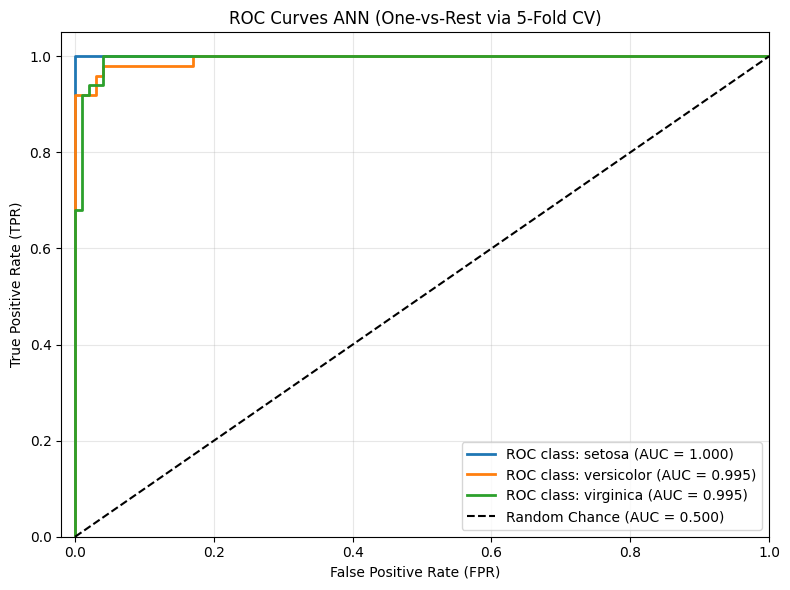

In [6]:
# Binarizzazione dei target (OvR): crea una matrice (150, 3) con valori 0 o 1
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

# Inizializzazione MLP e Cross-Validation
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Estrazione delle probabilità stimate (out-of-fold)
y_score = cross_val_predict(mlp, X, y, cv=cv, method='predict_proba')

# Calcolo di FPR, TPR e AUC per ciascuna classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Visualizzazione grafica delle curve ROC
plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"ROC class: {class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Baseline (Classificatore casuale)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves ANN (One-vs-Rest via 5-Fold CV)')
plt.legend(loc="lower right", frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3. get an artificial inflation of the Virginica class in the training set by a given factor: 10 (weigh more the class virginica which is difficult to discriminate with versicolor). Learn the ANN in this condition. In this case we have more examples in the dataset!

**Note:** Be careful in the random sampling when you divide the dataset into training- and test-set: no examples of the training-set should go in the test- set.


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

Campioni per classe nel Train Set originale: [35 35 35]
Campioni per classe nel Train Set gonfiato: [ 35  35 350]


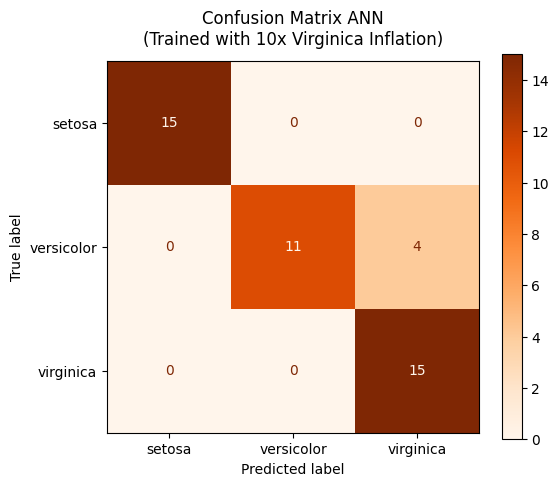

Classification Report ANN sul Test Set (Out-of-sample):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.73      0.85        15
   virginica       0.79      1.00      0.88        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



In [10]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Caricamento del dataset
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names

# Suddivisione Stratificata in Train/Test PRIMA dell'inflazione
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Campioni per classe nel Train Set originale: {np.bincount(y_train)}")

# Isolamento e inflazione della classe Virginica (label 2) nel Training Set
virginica_mask = (y_train == 2)
X_virginica = X_train[virginica_mask]
y_virginica = y_train[virginica_mask]

# Replicazione per ottenere un fattore 10 (l'originale + 9 copie)
inflation_factor = 10
X_virginica_inflated = np.repeat(X_virginica, inflation_factor - 1, axis=0)
y_virginica_inflated = np.repeat(y_virginica, inflation_factor - 1, axis=0)

# Assemblaggio del nuovo Training Set gonfiato
X_train_inflated = np.vstack([X_train, X_virginica_inflated])
y_train_inflated = np.concatenate([y_train, y_virginica_inflated])

print(f"Campioni per classe nel Train Set gonfiato: {np.bincount(y_train_inflated)}")

# Inizializzazione e Addestramento ANN sul set gonfiato
mlp_inflated = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
mlp_inflated.fit(X_train_inflated, y_train_inflated)

# Predizione sul Test Set intatto
y_pred_test = mlp_inflated.predict(X_test)

# Matrice di confusione
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Oranges, values_format='d', ax=ax)
plt.title("Confusion Matrix ANN\n(Trained with 10x Virginica Inflation)", pad=12)
plt.show()

# Classification Report
print("Classification Report ANN sul Test Set (Out-of-sample):\n")
print(classification_report(y_test, y_pred_test, target_names=class_names))

### 4. learn the ANN but try to avoid overfitting (by improving the error on the test set). You can do tuning of the hyper-parameters using the function [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

Consider the following hyperparameters:

- hidden_layer_sizes
- activation = {‘identity’, ‘logistic’, ‘tanh’, ‘relu’}
- solver = {‘lbfgs’, ‘sgd’, ‘adam’}
- alpha (L2 regularization term)
- batch_size (size of the mini-batch)
- learning_rate = {‘constant’, ‘invscaling’, ‘adaptive’}
- early_stopping: bool
- warm_start: bool
- max_iter

Decide yourself the suitable possible values for each of them.

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

MIGLIORI IPERPARAMETRI TROVATI:
 - activation          : relu
 - alpha               : 0.01
 - batch_size          : 32
 - early_stopping      : False
 - hidden_layer_sizes  : (5, 2)
 - learning_rate       : constant
 - max_iter            : 1000
 - solver              : adam
 - warm_start          : False

Accuratezza finale sul Test Set: 0.9778

Classification Report ANN Ottimizzata:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



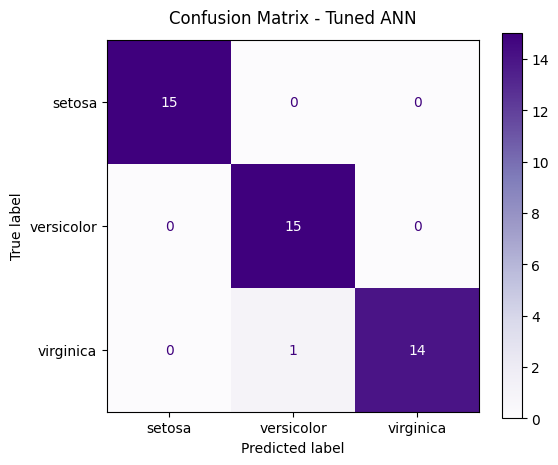

In [12]:
# Definizione della griglia di iperparametri
# Nota: warm_start=True è utile solo per addestramenti iterativi custom, lo impostiamo a False.
param_grid = {
    'hidden_layer_sizes': [(5, 2), (10, 10), (20,)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.01, 0.1],
    'batch_size': ['auto', 32],
    'learning_rate': ['constant', 'adaptive'],
    'early_stopping': [True, False],
    'warm_start': [False],
    'max_iter': [1000]
}

# Inizializzazione modello base e Cross-Validation
base_mlp = MLPClassifier(random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurazione GridSearchCV[cite: 1]
grid_search_mlp = GridSearchCV(
    estimator=base_mlp,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,        # Usa tutti i core disponibili per velocizzare
    verbose=1         # Mostra log di avanzamento
)

# Esecuzione della ricerca (sul Train Set originario, NON gonfiato)
grid_search_mlp.fit(X_train, y_train)

# Estrazione e stampa della configurazione ottimale
best_mlp = grid_search_mlp.best_estimator_
print("\nMIGLIORI IPERPARAMETRI TROVATI:")
for param, value in grid_search_mlp.best_params_.items():
    print(f" - {param:20s}: {value}")

# Valutazione sul Test Set (Out-of-sample)
y_pred_best_mlp = best_mlp.predict(X_test)
print(f"\nAccuratezza finale sul Test Set: {accuracy_score(y_test, y_pred_best_mlp):.4f}\n")
print("Classification Report ANN Ottimizzata:\n")
print(classification_report(y_test, y_pred_best_mlp, target_names=class_names))

# Matrice di Confusione
fig, ax = plt.subplots(figsize=(6, 5))
cm_best = confusion_matrix(y_test, y_pred_best_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=class_names)
disp.plot(cmap=plt.cm.Purples, values_format='d', ax=ax)
plt.title("Confusion Matrix - Tuned ANN", pad=12)
plt.show()

### 5. build the ROC curves of best models (obtained after hyperparameter tuning) for both DT and ANN for each of the three classes (with *one-vs-rest* methodology). Compare the two models.

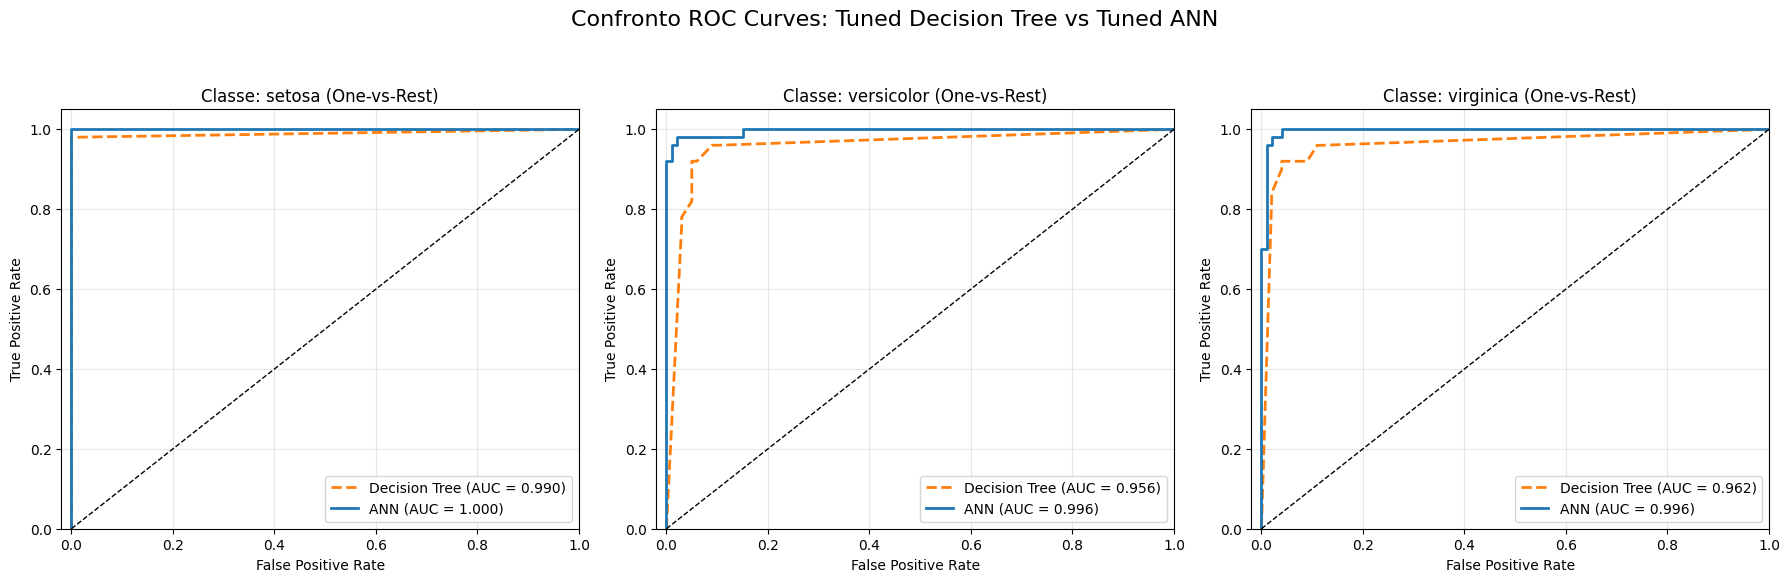

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Binarizzazione dei target per approccio One-vs-Rest
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Inizializzazione modelli ottimizzati
# Decision Tree con i parametri estratti dal tuo GridSearchCV
best_tree_model = DecisionTreeClassifier(
    ccp_alpha=0.0,
    criterion='gini',
    max_depth=None,
    max_features=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=1,
    min_samples_split=10,
    splitter='random',
    random_state=42
)

# Assumiamo che 'best_mlp' sia ancora in memoria dall'esecuzione del Punto 4
# In caso contrario, sostituisci con i best_params_ trovati per la rete neurale.

# Estrazione probabilità out-of-fold per entrambi i modelli
y_score_dt = cross_val_predict(best_tree_model, X, y, cv=cv, method='predict_proba')
y_score_mlp = cross_val_predict(best_mlp, X, y, cv=cv, method='predict_proba')

# Visualizzazione grafica comparativa in 3 riquadri
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Confronto ROC Curves: Tuned Decision Tree vs Tuned ANN', fontsize=16, y=1.05)

for i in range(n_classes):
    # Calcolo metriche per Decision Tree
    fpr_dt, tpr_dt, _ = roc_curve(y_bin[:, i], y_score_dt[:, i])
    auc_dt = auc(fpr_dt, tpr_dt)

    # Calcolo metriche per Rete Neurale (ANN)
    fpr_mlp, tpr_mlp, _ = roc_curve(y_bin[:, i], y_score_mlp[:, i])
    auc_mlp = auc(fpr_mlp, tpr_mlp)

    # Disegno delle curve sul rispettivo asse
    axes[i].plot(fpr_dt, tpr_dt, color='#ff7f0e', lw=2, linestyle='--',
                 label=f'Decision Tree (AUC = {auc_dt:.3f})')
    axes[i].plot(fpr_mlp, tpr_mlp, color='#1f77b4', lw=2,
                 label=f'ANN (AUC = {auc_mlp:.3f})')

    # Baseline
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)

    axes[i].set_xlim([-0.02, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'Classe: {class_names[i]} (One-vs-Rest)')
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()